In [10]:
# Кейс №57: Классификация спама по тексту электронного письма
# Автор: студентка группы ЕТ-142 Ермакова Софья Юрьевна

# Импорт необходимых библиотек
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split

# Загрузка используемого датасета с гугл диска
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/My Drive/spambase/spambase.data", header=None)

# 57 признаков + 1 метка = 58 колонок
df.columns = [f"f_{i}" for i in range(1, 58)] + ["label"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


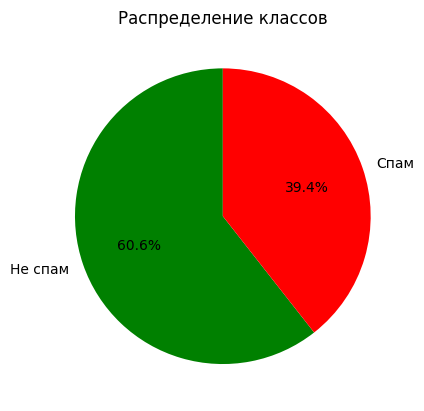

Не спам: 2788 (60.6%)
Спам:    1813 (39.4%)


In [5]:
# Диаграмма "Распределение классов"

counts = df["label"].value_counts().sort_index()

plt.pie(counts, labels=["Не спам", "Спам"], autopct="%1.1f%%",
        colors=["green", "red"], startangle=90)
plt.title("Распределение классов")
plt.show()

print(f"Не спам: {counts[0]} ({counts[0]/counts.sum()*100:.1f}%)")
print(f"Спам:    {counts[1]} ({counts[1]/counts.sum()*100:.1f}%)")

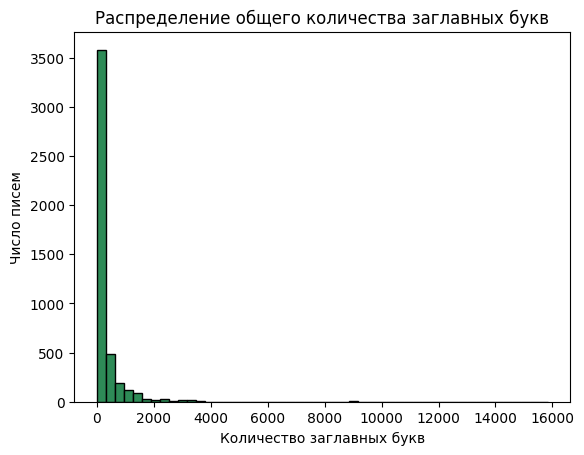

count     4601.000000
mean       283.289285
std        606.347851
min          1.000000
25%         35.000000
50%         95.000000
75%        266.000000
max      15841.000000
Name: f_57, dtype: float64


In [6]:
# Общее количество заглавных букв — косвенный показатель длины письма

plt.hist(df["f_57"], bins=50, color="seagreen", edgecolor="black")
plt.title("Распределение общего количества заглавных букв")
plt.xlabel("Количество заглавных букв")
plt.ylabel("Число писем")
plt.show()

print(df["f_57"].describe())

In [12]:
# Разделение датасета на train, val и test выборки

# Создание папки
os.makedirs("data", exist_ok=True)

# Разделение 70/15/15
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Сохранение
train = X_train.copy(); train["label"] = y_train.values
val   = X_val.copy();   val["label"]   = y_val.values
test  = X_test.copy();  test["label"]  = y_test.values

train.to_csv("data/train.csv", index=False)
val.to_csv("data/val.csv", index=False)
test.to_csv("data/test.csv", index=False)

print(f"data/train.csv — {len(train)} строк")
print(f"data/val.csv   — {len(val)} строк")
print(f"data/test.csv  — {len(test)} строк")

data/train.csv — 3220 строк
data/val.csv   — 690 строк
data/test.csv  — 691 строк


In [14]:
# Примеры строк: спам и не спам

print("Примеры строк из датасета")

# Первое письмо - спам
spam_sample = df[df["label"] == 1].iloc[0]
print("\nСпам (label = 1):")
print(f"  word_freq_free (частота 'free'):     {spam_sample['f_16']:.2f}")
print(f"  word_freq_credit (частота 'credit'): {spam_sample['f_20']:.2f}")
print(f"  char_freq_! (частота '!'):           {spam_sample['f_52']:.2f}")
print(f"  char_freq_$ (частота '$'):           {spam_sample['f_53']:.2f}")
print(f"  capital_run_length_average:          {spam_sample['f_55']:.2f}")
print(f"  capital_run_length_longest:          {spam_sample['f_56']:.0f}")
print(f"  capital_run_length_total:            {spam_sample['f_57']:.0f}")

# Первое письмо - не спам
ham_sample = df[df["label"] == 0].iloc[0]
print("\nНе спам (label = 0):")
print(f"  word_freq_free (частота 'free'):     {ham_sample['f_16']:.2f}")
print(f"  word_freq_credit (частота 'credit'): {ham_sample['f_20']:.2f}")
print(f"  char_freq_! (частота '!'):           {ham_sample['f_52']:.2f}")
print(f"  char_freq_$ (частота '$'):           {ham_sample['f_53']:.2f}")
print(f"  capital_run_length_average:          {ham_sample['f_55']:.2f}")
print(f"  capital_run_length_longest:          {ham_sample['f_56']:.0f}")
print(f"  capital_run_length_total:            {ham_sample['f_57']:.0f}")

Примеры строк из датасета

Спам (label = 1):
  word_freq_free (частота 'free'):     0.32
  word_freq_credit (частота 'credit'): 0.00
  char_freq_! (частота '!'):           0.78
  char_freq_$ (частота '$'):           0.00
  capital_run_length_average:          3.76
  capital_run_length_longest:          61
  capital_run_length_total:            278

Не спам (label = 0):
  word_freq_free (частота 'free'):     0.00
  word_freq_credit (частота 'credit'): 0.00
  char_freq_! (частота '!'):           0.02
  char_freq_$ (частота '$'):           0.02
  capital_run_length_average:          3.48
  capital_run_length_longest:          5
  capital_run_length_total:            5902
